In [75]:
from datasets import load_dataset, concatenate_datasets
import pandas as pd
from pathlib import Path
import numpy as np

from sklearn.base import clone
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_fscore_support

import matplotlib.pyplot as plt
import seaborn as sns

import re
import unicodedata
import time

from pythainlp.tokenize import word_tokenize

In [76]:
LABEL_NAMES = {
    0: "positive",
    1: "neutral",
    2: "negative",
}

RANDOM_STATE = 42
TEST_SIZE = 0.2

## 1. Data Exploration

In [77]:
ds = load_dataset("pythainlp/wisesight_sentiment")

In [78]:
train_df = ds["train"].to_pandas()
val_df = ds["validation"].to_pandas()
test_df = ds["test"].to_pandas()

train_df["dataset_type"] = "train"
val_df["dataset_type"] = "validation"
test_df["dataset_type"] = "test"

df = pd.concat(
    [train_df, val_df, test_df],
    ignore_index=True
)

df.head(5)

,texts,category,dataset_type
0,ไปจองมาแล้วนาจา Mitsubishi Attrage ได้หลังสงกร...,1,train
1,เปิดศักราชใหม่! นายกฯ แถลงข่าวก่อนการแข่งขันศึ...,1,train
2,บัตรสมาชิกลดได้อีกไหมคับ,1,train
3,สนใจ new mazda2ครับ,1,train
4,😍😍,0,train


In [79]:
output_dir = Path("../data/raw")
output_dir.mkdir(parents=True, exist_ok=True)

df.to_csv(
    output_dir / "data.csv",
    index=False
)

## 2. Data Preprocessing

In [80]:
display(df.isna().sum())

texts           0
category        0
dataset_type    0
dtype: int64

In [81]:
label_count = (
    df.groupby("texts")["category"].transform("nunique")
)

conflict_rows = df[
    label_count > 1
].copy()

display(
    conflict_rows.sort_values(
        ["texts", "dataset_type", "category"]
    )
)

,texts,category,dataset_type
9278,toyota ผมแนะนำถ้าใครซื้ออย่าเอารถค้างสต็อคตามป...,0,train
4977,toyota ผมแนะนำถ้าใครซื้ออย่าเอารถค้างสต็อคตามป...,2,train
13250,ชุมพรมั้ยอ้ะ?!😂,0,train
7008,ชุมพรมั้ยอ้ะ?!😂,3,train
15561,ซีวิค มีส่วนลดเท่าไหร่ครับ,0,train
13932,ซีวิค มีส่วนลดเท่าไหร่ครับ,3,train
26163,นกแอร์กับแอร์เอเชียเที่ยวบินไประนองยกเลิกมั้ยค่ะ,1,test
3214,นกแอร์กับแอร์เอเชียเที่ยวบินไประนองยกเลิกมั้ยค่ะ,3,train
19476,น้องอยากกิน,1,train
23817,น้องอยากกิน,0,validation


In [82]:
df_clean = df[
    label_count == 1
].copy()

In [83]:
#clean text
def clean_text(text):
    text = unicodedata.normalize("NFC", str(text))
    text = re.sub(r"<[^>]+>", " ", text)
    text = re.sub(r"https?://\S+|www\.\S+", " URL ", text)
    text = re.sub(r"@\w+", "USER", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

df_clean["texts_clean"] = df_clean["texts"].apply(clean_text)

In [84]:
df_clean["sentiment"] = df_clean["category"].map(LABEL_NAMES)
df_clean[df_clean["sentiment"] != "question"]
df_clean.head(5)

,texts,category,dataset_type,texts_clean,sentiment
0,ไปจองมาแล้วนาจา Mitsubishi Attrage ได้หลังสงกร...,1,train,ไปจองมาแล้วนาจา Mitsubishi Attrage ได้หลังสงกร...,neutral
1,เปิดศักราชใหม่! นายกฯ แถลงข่าวก่อนการแข่งขันศึ...,1,train,เปิดศักราชใหม่! นายกฯ แถลงข่าวก่อนการแข่งขันศึ...,neutral
2,บัตรสมาชิกลดได้อีกไหมคับ,1,train,บัตรสมาชิกลดได้อีกไหมคับ,neutral
3,สนใจ new mazda2ครับ,1,train,สนใจ new mazda2ครับ,neutral
4,😍😍,0,train,😍😍,positive


In [85]:
df_clean.value_counts(subset="sentiment")

sentiment
neutral     14532
negative     6808
positive     4762
Name: count, dtype: int64

In [86]:
output_dir = Path("../data/processed")
output_dir.mkdir(parents=True, exist_ok=True)

df_clean.to_csv(
    output_dir / "data.csv",
    index=False
)

## 3. Model Training

In [87]:
X_train = df_clean[df_clean["dataset_type"] == "train"]["texts_clean"]
y_train = df_clean[df_clean["dataset_type"] == "train"]["category"]

X_val = df_clean[df_clean["dataset_type"] == "validation"]["texts_clean"]
y_val = df_clean[df_clean["dataset_type"] == "validation"]["category"]

In [88]:
print("Train dataset shape:", X_train.shape[0])
print("Validation dataset shape:", X_val.shape[0])

Train dataset shape: 21589
Validation dataset shape: 2400


In [89]:
def thai_tokenizer(text):
    return word_tokenize(
        text,
        engine="newmm",
        keep_whitespace=False
    )

features = FeatureUnion([
    (
        "char_tfidf",
        TfidfVectorizer(
            analyzer="char",
            ngram_range=(2, 6),
            min_df=2,
            max_df=0.98,
            max_features=150_000,
            sublinear_tf=True
        )
    ),
    (
        "word_tfidf",
        TfidfVectorizer(
            tokenizer=thai_tokenizer,
            token_pattern=None,
            ngram_range=(1, 2),
            min_df=2,
            max_df=0.98,
            max_features=100_000,
            sublinear_tf=True
        )
    )
])

# tfidf = TfidfVectorizer(
#     analyzer="char",
#     ngram_range=(2, 5),
#     max_features=100_000,
#     sublinear_tf=True
# )

classifiers = {
    "Dummy Classifier": DummyClassifier(
        strategy="most_frequent",
    ),
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=RANDOM_STATE,
    ),
    "Linear SVM": LinearSVC(
        class_weight="balanced",
        random_state=RANDOM_STATE
    ),
    "Naive Bayes": MultinomialNB(
        alpha=1.0
    ),
    "SGD Classifier": SGDClassifier(
        loss="log_loss",
        max_iter=1000,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        early_stopping=True
    )
}

In [90]:
#Models

models = {
    model_name: Pipeline([
        ("feature", features),
        ("classifier", classifier)
    ])
    for model_name, classifier in classifiers.items()
}


In [91]:
experiment_results = []
trained_models = {}
validation_predictions = {}

for model_name, current_model in models.items():

    print(f"Training: {model_name}")

    start_time = time.perf_counter()
    current_model.fit(X_train, y_train)
    training_time = time.perf_counter() - start_time

    start_time = time.perf_counter()
    y_pred = current_model.predict(X_val)
    prediction_time = time.perf_counter() - start_time

    precision, recall, macro_f1, _ = (
        precision_recall_fscore_support(
            y_val,
            y_pred,
            average="macro",
            zero_division=0
        )
    )

    weighted_f1 = precision_recall_fscore_support(
        y_val,
        y_pred,
        average="weighted",
        zero_division=0
    )[2]

    result = {
        "model": model_name,
        "accuracy": round(accuracy_score(y_val, y_pred), 4),
        "macro_precision": round(precision, 4),
        "macro_recall": round(recall, 4),
        "macro_f1": round(macro_f1, 4),
        "weighted_f1": round(weighted_f1, 4),
        "training_time_s": round(training_time, 3),
        "prediction_time_s": round(prediction_time, 3)
    }

    experiment_results.append(result)

    trained_models[model_name] = current_model
    validation_predictions[model_name] = y_pred

Training: Dummy Classifier
Training: Logistic Regression
Training: Linear SVM
Training: Naive Bayes
Training: SGD Classifier


In [92]:
results_df = pd.DataFrame(experiment_results).sort_values(by="macro_f1", ascending=False).reset_index(drop=True)
display(results_df)

,model,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,training_time_s,prediction_time_s
0,Logistic Regression,0.6908,0.5700,0.6609,0.5978,0.6956,29.229,1.141
1,SGD Classifier,0.7033,0.5768,0.5936,0.5794,0.7000,18.115,1.187
2,Linear SVM,0.7025,0.5820,0.5541,0.5652,0.6989,21.149,1.129
3,Naive Bayes,0.6779,0.5236,0.4225,0.4243,0.6355,17.689,1.171
4,Dummy Classifier,0.5375,0.1344,0.2500,0.1748,0.3758,17.438,1.178


In [93]:
#Best Model Select

best_model_name = results_df.loc[0, "model"]
best_model = trained_models[best_model_name]
best_y_pred = validation_predictions[best_model_name]

In [94]:
param_grid = {
    "classifier__C": [0.1, 0.5, 1.0],
    "classifier__class_weight": [
        None,
        "balanced",
    ]
}

In [95]:
grid_search = GridSearchCV(
    estimator=best_model,
    param_grid=param_grid,
    scoring="f1_macro",
    cv=5,
    n_jobs=-1,
    verbose=2,
    return_train_score=True,
)

In [96]:
grid_search.fit(X_train, y_train);

Fitting 5 folds for each of 6 candidates, totalling 30 fits


In [101]:
print("Best parameters:", grid_search.best_params_)
print("CV Macro F1:", grid_search.best_score_)

val_pred = grid_search.best_estimator_.predict(X_val)

Best parameters: {'classifier__C': 1.0, 'classifier__class_weight': 'balanced'}
CV Macro F1: 0.59764293697137


## 4. Model Evaluation

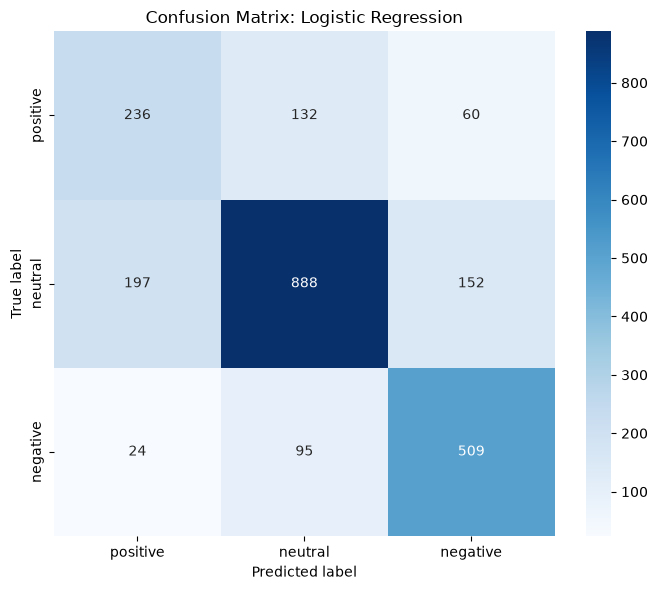

In [102]:
#Confusion Matrix
LABEL_IDS = list(LABEL_NAMES.keys())
LABEL_TEXTS = list(LABEL_NAMES.values())

cm = confusion_matrix(
    y_val,
    val_pred,
    labels=LABEL_IDS
)

plt.figure(figsize=(7, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=LABEL_TEXTS,
    yticklabels=LABEL_TEXTS
)

plt.title(f"Confusion Matrix: {best_model_name}")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.tight_layout()
plt.show()

In [103]:
#Error Analysis


error_df = pd.DataFrame({
  "text": X_val.reset_index(drop=True),
  "true_label": y_val.reset_index(drop=True),
  "predicted_label": pd.Series(val_pred)  
})

error_df["true_sentiment"] = (
    error_df["true_label"].map(LABEL_NAMES)
)

error_df["predicted_sentiment"] = (
    error_df["predicted_label"].map(LABEL_NAMES)
)

error_df = error_df[
    error_df["true_label"] != error_df["predicted_label"]
].copy()

display(error_df.head(30))



,text,true_label,predicted_label,true_sentiment,predicted_sentiment
4,สนามบินไหนไม่แพงล่ะครับบ ชางฮี เชคแลบก๊ก เจเอฟ...,1,2,neutral,negative
9,ได้ค้าบได้ รอพอทจังก่อนน้า T^T,2,0,negative,positive
10,จัดกันนตัวเอง,1,0,neutral,positive
11,285 มันขม เหล้าขาวสักกลมพอ..,1,2,neutral,negative
12,ตามใจ รำคาญ,2,1,negative,neutral
16,ก้อยขม ต้มแซบ เบียร์ช้างเย็นๆคับ😀😬,1,0,neutral,positive
17,เปิดพรี ETUDE MATCH TINT SET ลด50%สินค้ามีจำกั...,2,1,negative,neutral
18,รอครับพี่,1,0,neutral,positive
27,อยากได้กะบะออโต้หรือรถhondajazz,0,1,positive,neutral
31,อยู่แถวสยามสแควร์ มีหัวปลาให้สั่งลงไปต้มในหม้อ...,2,0,negative,positive


In [108]:
error_summary = (
    error_df.groupby(
        ["true_sentiment", "predicted_sentiment"]
    )
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

display(error_summary)

,true_sentiment,predicted_sentiment,count
3,neutral,positive,197
2,neutral,negative,152
5,positive,neutral,132
0,negative,neutral,95
4,positive,negative,60
1,negative,positive,24
